<div class="summary-hero">
<div class="eyebrow">PROJECT SUMMARY · SENTINEL-2 / U-NET</div>
<h1>Satellite Water Segmentation</h1>
<p class="subtitle">RGB versus RGB+NIR · A New York City case study</p>
<p>Train and evaluate on public pixel labels, then apply the fixed models to NYC imagery and compare their outputs with ground observations.</p>
</div>

**Research question: How does adding near-infrared information change U-Net water segmentation, and how does this difference appear in an NYC application?**

The report follows **data → method → experiment → benchmark results → NYC application → conclusions**. All main model results use the final experiment in Notebook 08.

In [1]:
from pathlib import Path
import csv, json, html
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Image, Markdown

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
OUT = ROOT / 'outputs/project_summary'
SOURCES = OUT / 'source_images'
RUN = ROOT / 'outputs/cloud_logs/nyc_inference/nyc_l1c_20260921_013008_456262'
OUT.mkdir(parents=True, exist_ok=True)
cfg = json.loads((RUN / 'inference_config.json').read_text(encoding='utf-8'))
with (ROOT / 'outputs/nyc_point_validation/point_matches.csv').open(encoding='utf-8-sig') as f:
    points = list(csv.DictReader(f))
plt.rcParams.update({
    'font.family': ['Arial', 'DejaVu Sans'], 'font.size': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 1.2, 'legend.frameon': False, 'svg.fonttype': 'none',
    'figure.facecolor': 'white', 'figure.dpi': 120,
})

import sys, base64
sys.path.insert(0, str(ROOT / 'scripts'))
from paper_figures import build_all
metrics = [
    dict(model='rgb', split='test', epoch=18, mean_iou=.2028, global_iou=.3698, f1=.5399, precision=.4374, recall=.7052),
    dict(model='rgb_nir', split='test', epoch=18, mean_iou=.5150, global_iou=.7247, f1=.8404, precision=.7507, recall=.9544),
    dict(model='rgb', split='bolivia', epoch=18, mean_iou=.3337, global_iou=.4594, f1=.6296, precision=.4761, recall=.9293),
    dict(model='rgb_nir', split='bolivia', epoch=18, mean_iou=.5793, global_iou=.7908, f1=.8832, precision=.8263, recall=.9484),
]

PAPER = build_all(metrics, points)
COLORS = {'rgb': '#3775BA', 'rgb_nir': '#B64342'}

def figure(fig, name):
    fig.savefig(OUT / f'{name}.png', dpi=300, bbox_inches='tight')
    fig.savefig(OUT / f'{name}.svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)

def table(rows, columns):
    header = ''.join(f'<th>{html.escape(title)}</th>' for key, title in columns)
    def fmt(v):
        return f'{v:.4f}' if isinstance(v, float) else str(v)
    body = ''.join('<tr>' + ''.join(f'<td>{html.escape(fmt(r[key]))}</td>' for key, _ in columns) + '</tr>' for r in rows)
    display(HTML('<div class="table-scroll"><table><thead><tr>' + header + '</tr></thead><tbody>' + body + '</tbody></table></div>'))

def caption(text):
    display(HTML(f'<p class="caption">{html.escape(text)}</p>'))

display(HTML('<style>.jp-RenderedHTMLCommon table{border-collapse:collapse;border-top:1.5px solid #222;border-bottom:1.5px solid #222;width:100%;}.jp-RenderedHTMLCommon th{background:white;border-bottom:1px solid #555;padding:8px;}.jp-RenderedHTMLCommon td{padding:7px 8px;border:none;}.jp-RenderedHTMLCommon tr{background:white;}.caption{font:12px Arial,sans-serif;color:#333;line-height:1.55;}details img{max-width:100%;height:auto;}</style>'))

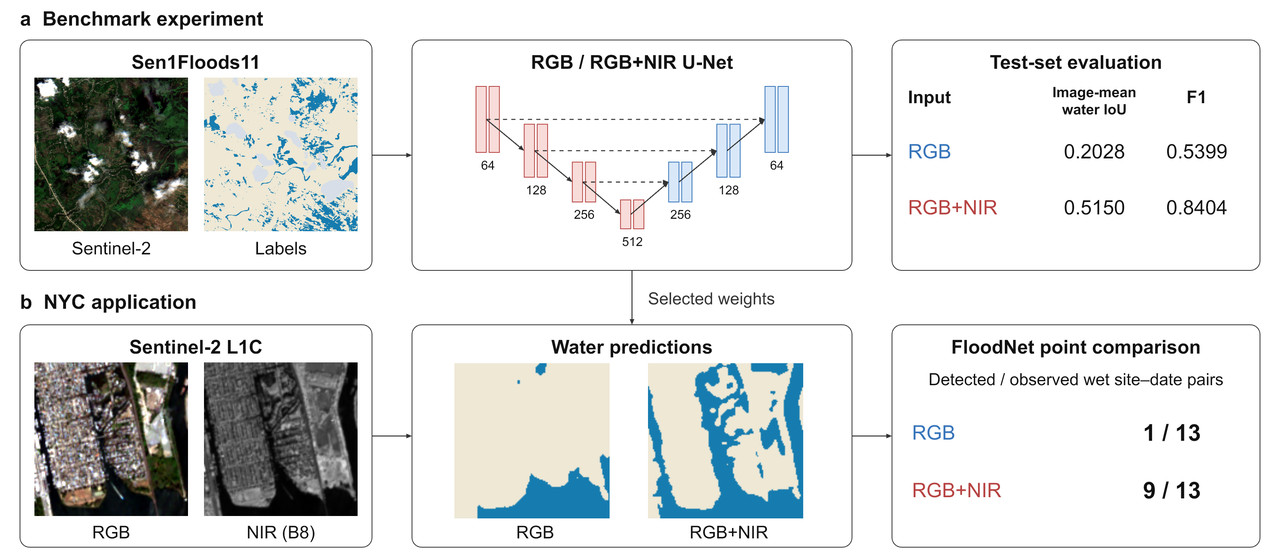

In [2]:
display(Image(filename=str(ROOT / 'outputs/method_figures/figure_1.png')))
caption('Overview | (a) RGB and RGB+NIR experiments on Sen1Floods11; image-mean water IoU averages the water-class IoU across images. (b) Fixed-model application to NYC, illustrated at Davenport. FloodNet counts summarize 13 wet site–date pairs across two dates; these are point detections, distinct from pixel metrics. Water masks include permanent water.')

## 01 · Data: labeled imagery and an NYC application

Two complementary sources support the study. **Sen1Floods11 supplies imagery and pixel labels for supervised training and evaluation. NYC imagery and FloodNet measurements support the application analysis.**

| Component | Coverage | Role |
|---|---|---|
| Sen1Floods11 hand-labeled subset | 446 Sentinel-2 image/label pairs, 512 × 512 pixels | Training and quantitative segmentation evaluation |
| Input bands | RGB: B4/B3/B2; RGB+NIR: B4/B3/B2/B8 | A three-band versus four-band comparison |
| Pixel labels | Water = 1, non-water = 0, ignored = -1 | Supervision and evaluation on shared valid pixels |
| NYC cases | 13 site–date windows at 10 sites; 21 September and 18 October 2024 | Application to coastal urban scenes |
| FloodNet | Depth sequences aligned with satellite overpass times | Ground observations at the sensor locations |

The training example below shows RGB, NIR, the human label and a label overlay. Adding NIR changes the available spectral information while retaining the same task and target labels.

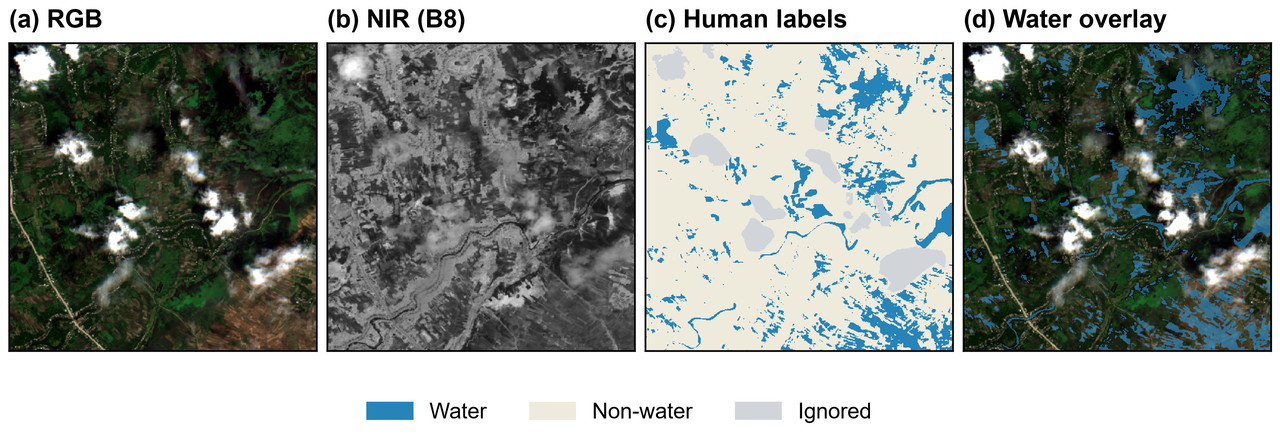

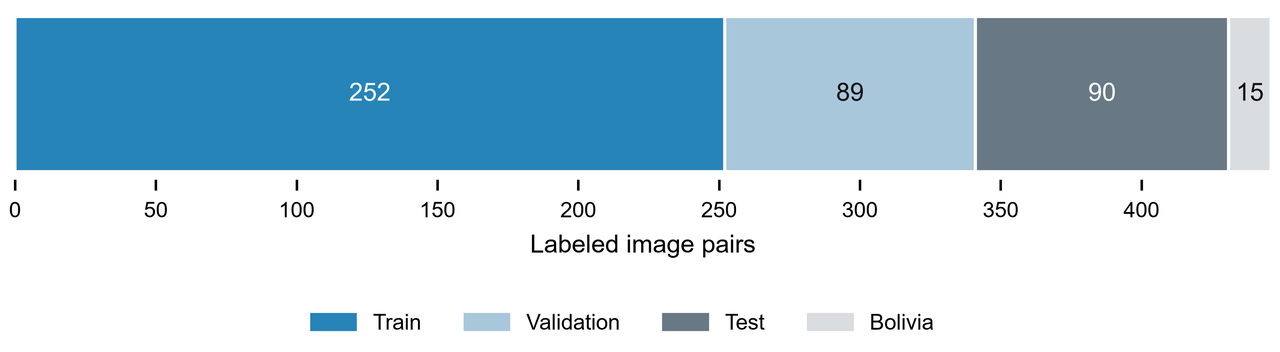

In [3]:
display(Image(filename=str(PAPER['training'])))
caption('Figure 1 | India_285297 training example: RGB, NIR, human labels and the water-label overlay. RGB uses a 2–98% display stretch; NIR uses a fixed reflectance range of 0–0.6. Labels are unchanged.')
display(Image(filename=str(PAPER['splits'])))
caption('Figure 2 | Official data partition: 252 training, 89 validation, 90 test and 15 Bolivia images. Both experiments use the same partition.')

## 02 · Method: the same U-Net with three or four bands

U-Net combines an encoder that extracts features at progressively coarser scales with a decoder that restores spatial detail. Skip connections carry fine-scale features into the decoder. The output is a non-water/water score pair for every pixel.

We adapt the public WorldFloods U-Net implementation: **64 → 128 → 256 → 512** channels, three downsampling stages, bilinear upsampling and ReLU activations. The two models use three or four input bands and learn their weights independently.

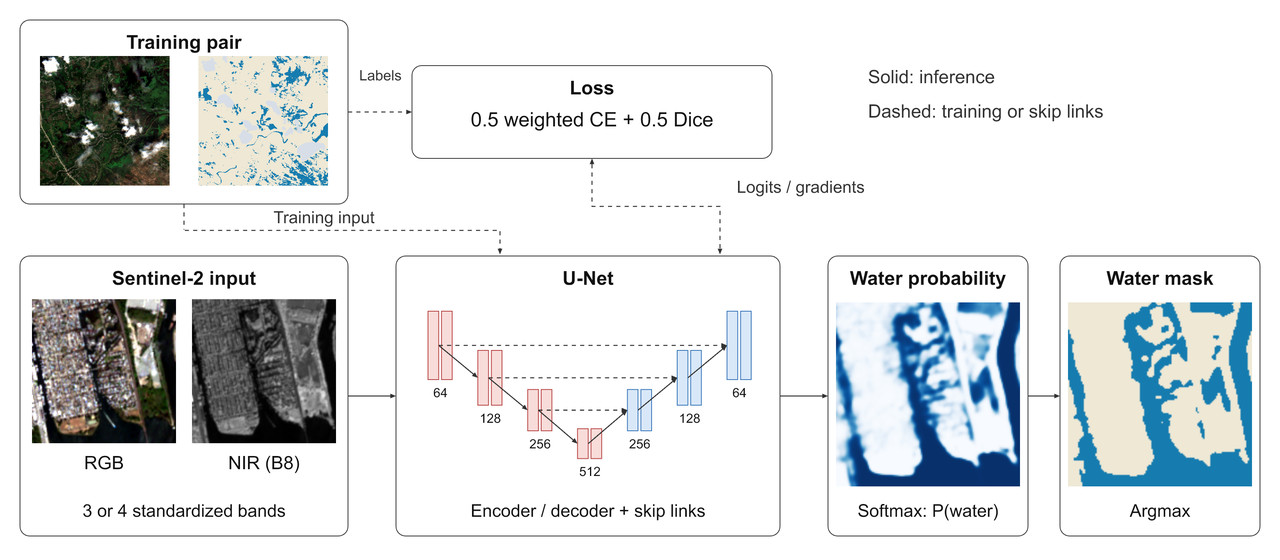

In [4]:
display(Image(filename=str(ROOT / 'outputs/method_figures/figure_2.png')))
caption('Figure 3 | U-Net training and inference. RGB uses B4/B3/B2; RGB+NIR adds B8. Both use TRAIN-derived standardization. Weighted CE and Dice use valid labels. Training pair: India_285297. Inference inputs and RGB+NIR outputs: Davenport, 21 September 2024. The two models share the architecture and training protocol, with independently learned weights.')

The processing sequence is:

**Image DN → reflectance → training-set standardization → U-Net → water probability → water/non-water mask.**

| Component | Implementation | Purpose |
|---|---|---|
| Band comparison | B4/B3/B2 versus B4/B3/B2/B8 | Measure the effect of adding NIR |
| Reflectance conversion | Training: DN/10000; these NYC products: (DN−1000)/10000 | Respect each product's encoding |
| Standardization | Per-band training mean and standard deviation | Keep preprocessing fixed during evaluation and application |
| Valid pixels | Shared label and four-band validity masks | Evaluate both models on the same pixels |
| Output | Two logits per pixel; softmax probabilities and argmax masks | Convert model scores into segmentation outputs |
| NYC windows | 512 × 512 context; central 128 × 128 export at 10 m | Map a 1.28 km neighborhood with surrounding context |

The models share the architecture, split, training budget and selection rule, apart from their input channels and corresponding first-layer dimensions.

## 03 · Experiment: a fixed public-method protocol

Each 512 × 512 training image supplies four non-overlapping 256 × 256 windows, giving **1008 training windows**. Both models trained for **25 epochs on an RTX 4090**. Minimum validation Dice loss selected epoch **18** for each model.

| Setting | Final value | Basis |
|---|---|---|
| Optimizer | Adam, learning rate 1×10⁻⁴, weight decay 0 | Selected public implementation |
| Batch size / epochs | 32 / 25 | Published training budget, shared by both models |
| Objective | 0.5 weighted cross-entropy + 0.5 Dice | Pixel classification and overlap |
| Class weights | Training N/n_c; approximately 1.105 non-water and 10.515 water | Class counts in the current dataset |
| Scheduler | Validation Dice plateau; factor 0.5, patience 2 | Validation-driven learning-rate adjustment |
| Model selection | Minimum validation Dice loss | The same rule for both inputs |
| Seed / augmentation | 12 / no extra augmentation | Fixed conditions and shared matching-layer initialization |
| Runtime | Single GPU, mixed precision | Execution on the available hardware |

**Image-mean water IoU** averages image-level overlap; **global water IoU** pools valid pixels before computing overlap. Precision reflects false positives, recall reflects missed water, and F1 combines both. The label mask is applied to both probabilities and targets in Dice, a documented adaptation of the public loss.

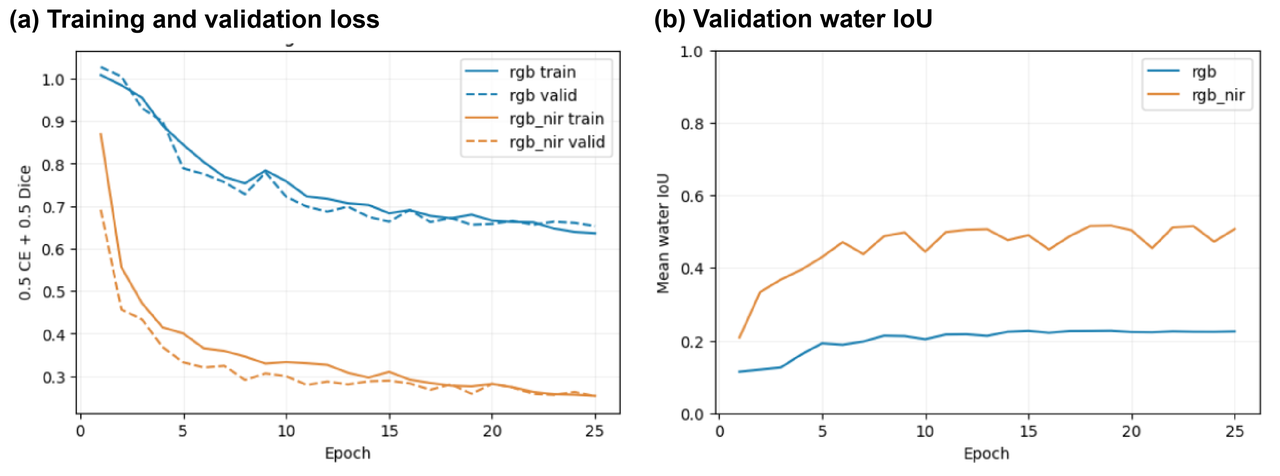

In [5]:
display(Image(filename=str(OUT.parent / 'paper_figures/03_training_record.png')))
caption('Figure 4 | Training and validation loss (a) and validation mean water IoU (b). Complete curve panels are reassembled from the original cloud record; curve pixels, axis values and colors are unchanged. Numerical epoch logs were not supplied.')

Both losses decrease during training, while RGB+NIR maintains higher validation IoU. The next section compares the validation-selected checkpoints on the same public test splits.

## 04 · Benchmark results: the contribution of NIR

Evaluate the **90-image test split** and the **15-image Bolivia split** separately. All values below come from the final Notebook 08 experiment and use the same metric definitions.

Split,Input,Image-mean water IoU,Global water IoU,F1,Precision,Recall
Test,RGB,0.2028,0.3698,0.5399,0.4374,0.7052
Test,RGB+NIR,0.5150,0.7247,0.8404,0.7507,0.9544
Bolivia,RGB,0.3337,0.4594,0.6296,0.4761,0.9293
Bolivia,RGB+NIR,0.5793,0.7908,0.8832,0.8263,0.9484


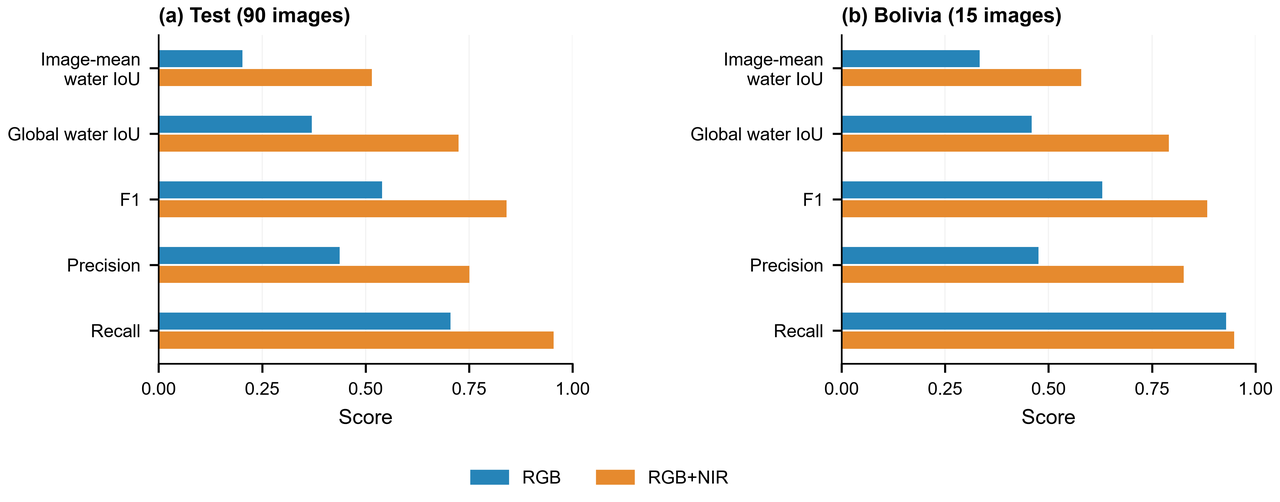

In [6]:
# Final notebook-08 cloud table, transcribed from the supplied original screenshot.
# The original is archived in source_images/metrics_table.png.
metrics = [
    dict(model='rgb', split='test', epoch=18, mean_iou=.2028, global_iou=.3698, f1=.5399, precision=.4374, recall=.7052),
    dict(model='rgb_nir', split='test', epoch=18, mean_iou=.5150, global_iou=.7247, f1=.8404, precision=.7507, recall=.9544),
    dict(model='rgb', split='bolivia', epoch=18, mean_iou=.3337, global_iou=.4594, f1=.6296, precision=.4761, recall=.9293),
    dict(model='rgb_nir', split='bolivia', epoch=18, mean_iou=.5793, global_iou=.7908, f1=.8832, precision=.8263, recall=.9484),
]
with (OUT / 'final08_metrics.csv').open('w', newline='', encoding='utf-8-sig') as f:
    writer = csv.DictWriter(f,fieldnames=list(metrics[0]))
    writer.writeheader(); writer.writerows(metrics)
labels = {'rgb':'RGB', 'rgb_nir':'RGB+NIR'}
table([{**r, 'model': labels[r['model']], 'split': r['split'].title()} for r in metrics], [('split','Split'),('model','Input'),('mean_iou','Image-mean water IoU'),('global_iou','Global water IoU'),('f1','F1'),('precision','Precision'),('recall','Recall')])
display(Image(filename=str(PAPER['benchmark'])))
caption('Table 1 / Figure 5 | Final test metrics in a selectable table; both IoU columns refer to water. Panels (a–b) compare all five metrics for the same selected weights. Single run per input, seed 12; no between-run uncertainty is estimated. Values are transcribed from the original final-experiment table.')

On the test split, adding NIR increases image-mean water IoU from **0.2028 to 0.5150** and F1 from **0.5399 to 0.8404**. Precision and recall also increase, indicating improvements in both false-positive and missed-water behavior in this experiment.

The Bolivia split shows the same direction of improvement. Global and mean IoU describe complementary aspects of performance: pooled pixel overlap and variation across individual images.

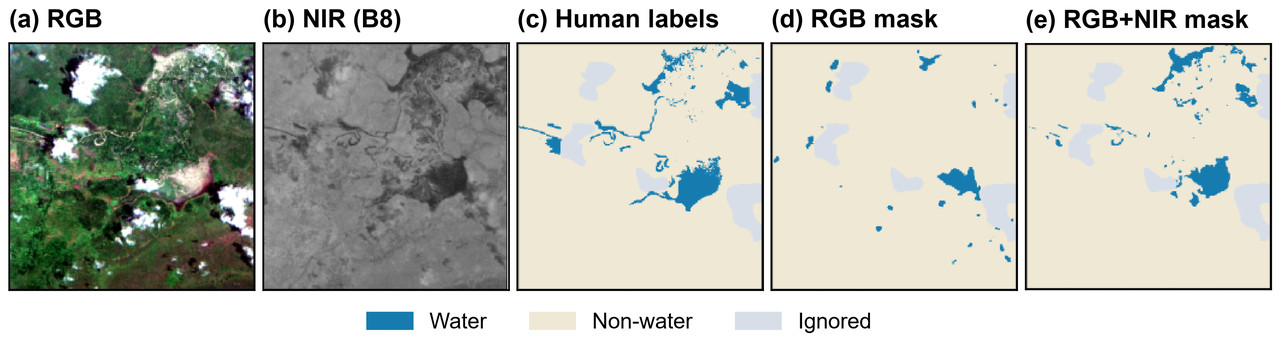

In [7]:
display(Image(filename=str(OUT.parent / 'paper_figures/04b_test_prediction_record.png')))
caption('Figure 6 | Ghana_313799: RGB, NIR, labels and model predictions, reassembled from complete panels in the original cloud-rendered record. Only surrounding layout and headings have changed; no predicted pixels are reconstructed.')

In this example, RGB+NIR recovers the lower-right water body more closely to the human label, while narrow channels and some boundaries remain incomplete. The benchmark metrics quantify the difference; the image comparison shows where it occurs.

We next apply the two fixed models to NYC's urban coastal scenes.

## 05 · NYC application: coastal urban water mapping

Sentinel-2 L1C imagery from **21 September and 18 October 2024** covers 13 site–date windows. The models produce water probabilities and masks, while FloodNet records ground-level water depth at the corresponding sensor locations and times.

The windows contain bays, channels, buildings and streets. **Blue denotes predicted water; red crosses locate the FloodNet sensors.** This supports both a spatial view of water predictions and a comparison at observed locations.

The following panels show Davenport on both dates, holding the location fixed to illustrate temporal variation.

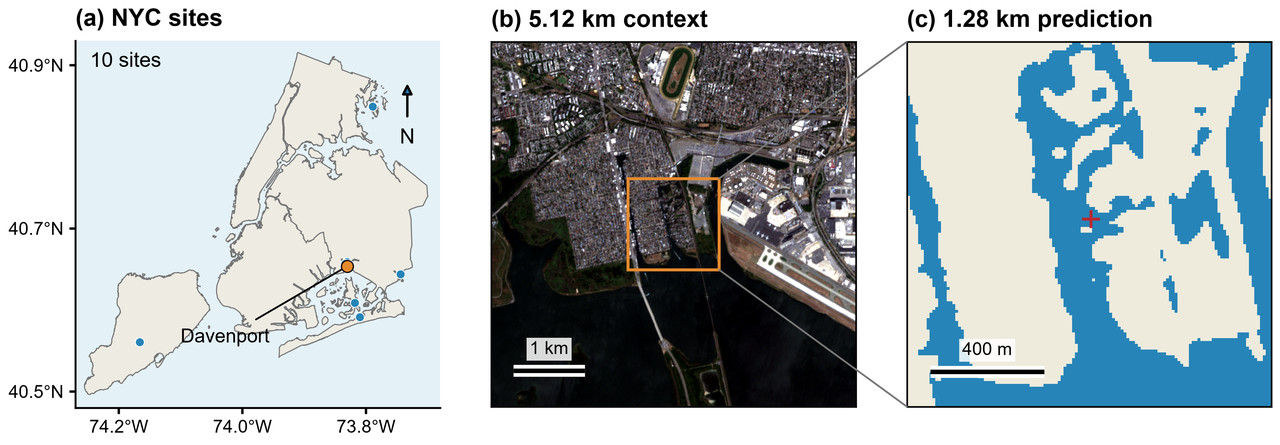

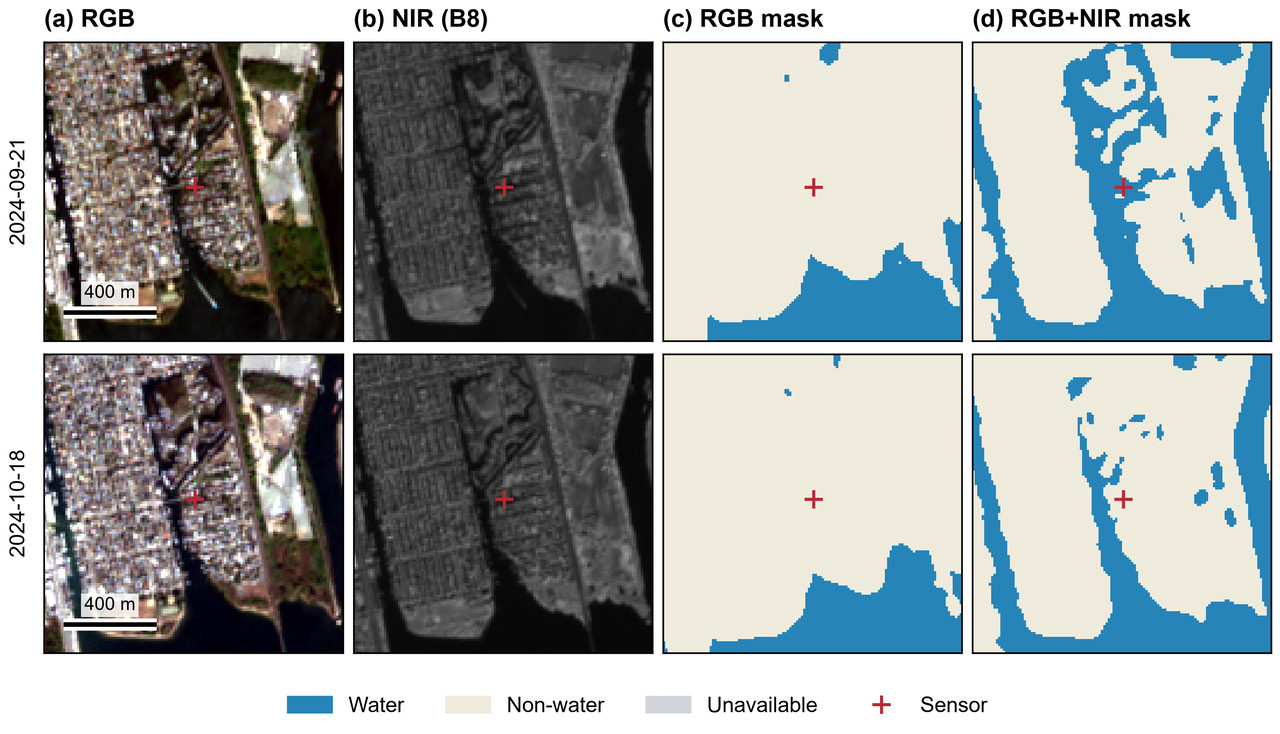

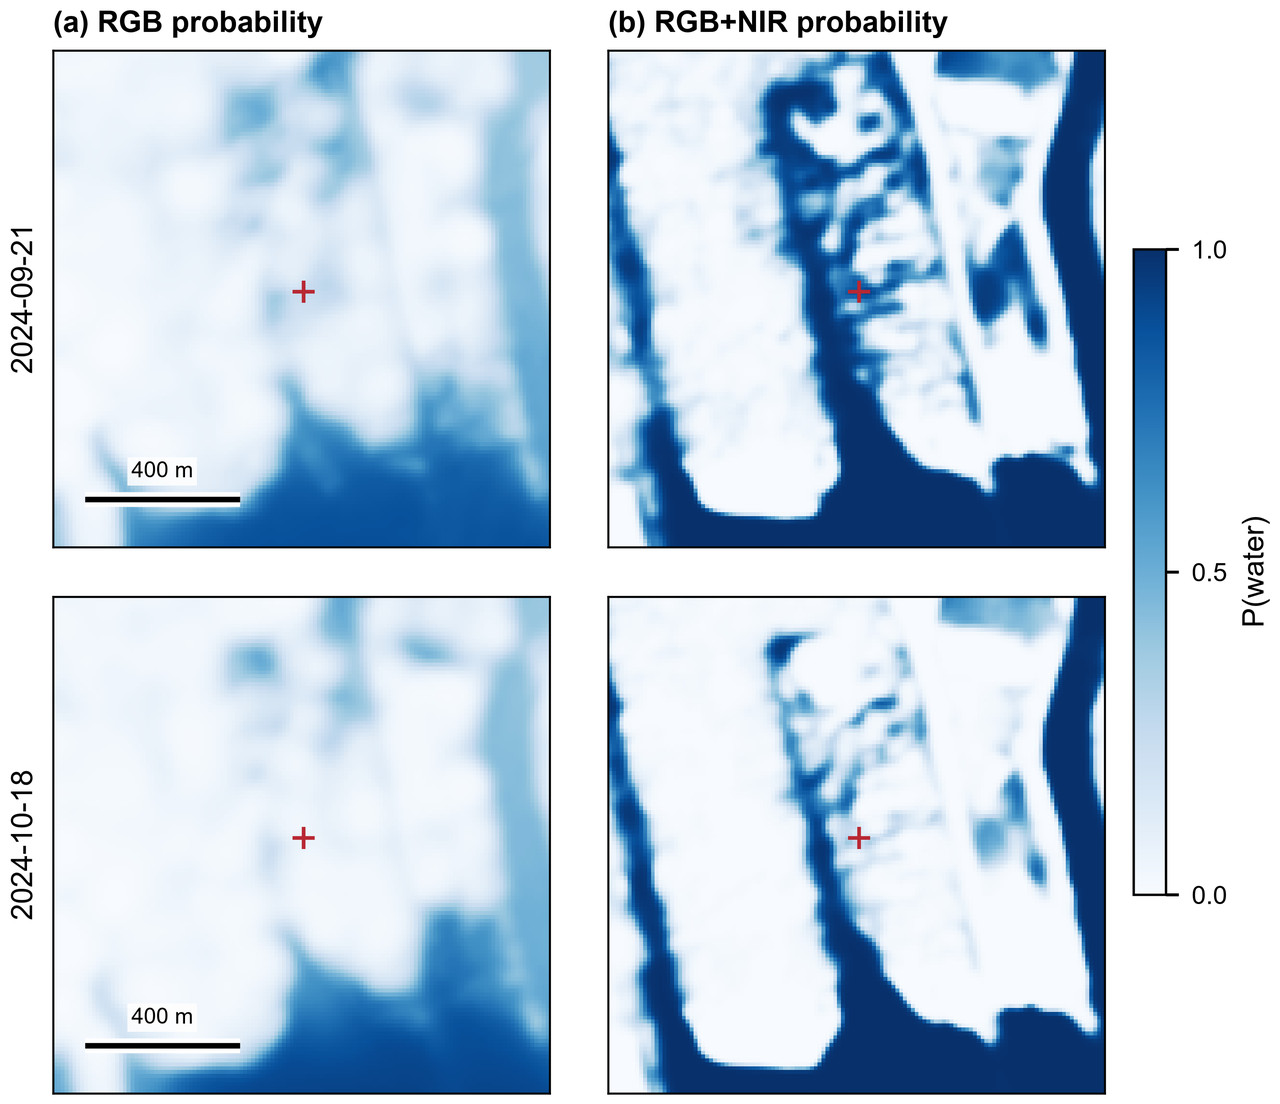

In [8]:
display(Image(filename=str(PAPER['locator'])))
caption('Figure 7 | (a) Ten NYC sensor locations. (b) Davenport: 5.12 km input context and the central inference window. (c) RGB+NIR prediction on 21 September 2024. Scale bars follow the raster geotransform. Borough outlines: NYC Department of City Planning; contextual cartography only.')
display(Image(filename=str(PAPER['nyc'])))
caption('Figure 8 | Davenport on two observation dates. Shared columns compare RGB, NIR and the two water masks. Both RGB images use one pooled 2–98% stretch; NIR uses 0–0.6 reflectance. Prediction grids are unchanged at 10 m. Blue: water; beige: non-water; grey: unavailable. Dates are not labeled as pre-/post-flood.')
probability_image = base64.b64encode(PAPER['probability'].read_bytes()).decode()
display(HTML('<details><summary>Supplementary probability maps</summary><img alt="Davenport water probabilities" src="data:image/png;base64,' + probability_image + '"><p class="caption">Both dates and both models use the same probability scale, 0–1.</p></details>'))

## 06 · Ground observations: comparison at sensor locations

Align catalog overpass times in UTC with FloodNet depth sequences and retain the measurements immediately before and after each overpass. All 13 sensor pixels are usable, and both bracketing measurements exceed 1 cm; measurement intervals range from **62 to 188 seconds**.

The bars summarize wet-site detections; the heatmap retains all 13 probability pairs. **RGB+NIR detects 9 pairs, compared with 1 for RGB**, with different results across the two dates.

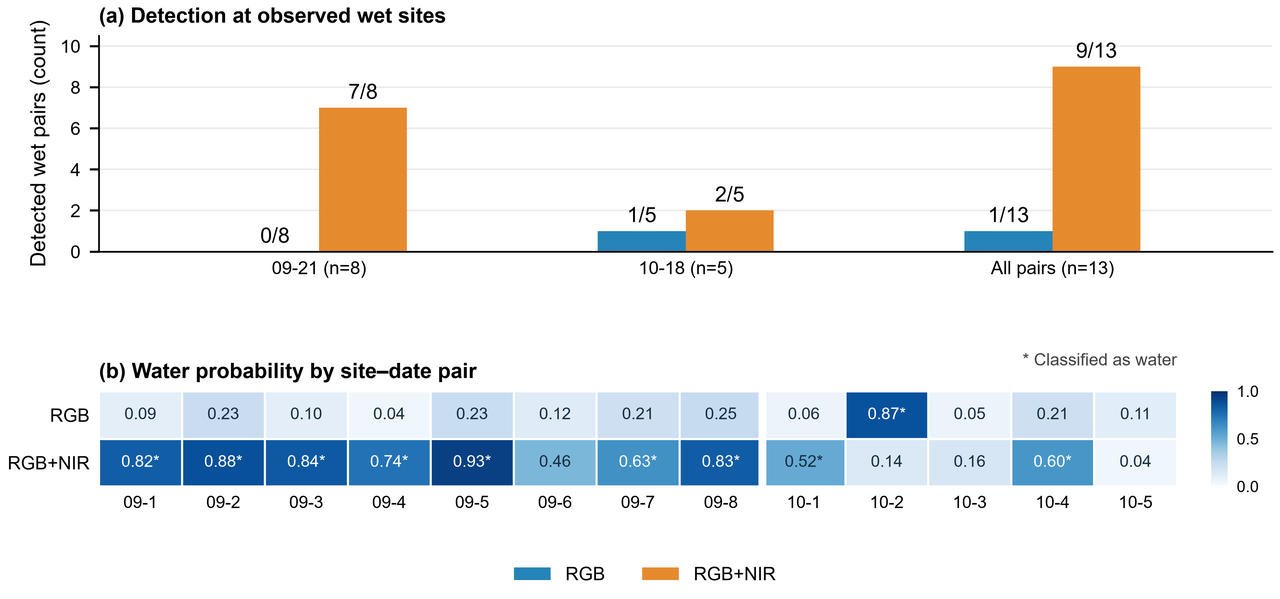

ID,Date,Site,Depth before (cm),Depth after (cm),RGB P(water),RGB+NIR P(water)
09-1,2024-09-21,Q - Beach 84 St,50.39,49.50,0.0946,0.8208
09-2,2024-09-21,Q - Davenport Ct 1,44.91,45.21,0.2294,0.8756
09-3,2024-09-21,Q - Russell St 1,26.39,26.29,0.0991,0.8401
09-4,2024-09-21,Q - 102nd St/160th Ave,18.39,18.29,0.0362,0.7445
09-5,2024-09-21,Q - 1st St/104th St,25.50,25.10,0.2309,0.9340
09-6,2024-09-21,Q - 161st Ave/99th St,15.80,14.71,0.1173,0.4590
09-7,2024-09-21,SI - Ridgewood Ave/Arthur Kill Rd,9.70,9.40,0.2135,0.6289
09-8,2024-09-21,Q - Church Rd/E 7th Rd,8.71,8.71,0.2483,0.8270
10-1,2024-10-18,Q - Russell St 1,1.80,1.60,0.0578,0.5155
10-2,2024-10-18,Q - Brookville Blvd/ Snake Rd 1,5.59,5.59,0.8732,0.1395


In [9]:
display(Image(filename=str(PAPER['points'])))
caption('Figure 9 | Ground-observation comparison. (a) Detected / observed wet pairs; bar heights show counts, with the observed sample size in each label. (b) All 13 pairs on a shared probability scale; * marks the exported water classification. IDs 09-1–09-8 and 10-1–10-5 refer to September 21 and October 18, 2024. Site names and measured depths are listed below.')

detail_rows=[]
for date in dict.fromkeys(r['date'] for r in points):
    for j,r in enumerate((r for r in points if r['date']==date),1):
        values=[f"{date[5:7]}-{j}",r['date'],r['sensor'],
                f"{float(r['depth_before_cm']):.2f}",f"{float(r['depth_after_cm']):.2f}",
                f"{float(r['rgb_probability']):.4f}",f"{float(r['rgb_nir_probability']):.4f}"]
        detail_rows.append('<tr>'+''.join('<td>'+html.escape(v)+'</td>' for v in values)+'</tr>')
headers=['ID','Date','Site','Depth before (cm)','Depth after (cm)','RGB P(water)','RGB+NIR P(water)']
display(HTML('<details><summary>All 13 observations: sites, depths and model probabilities</summary>'
             '<div class="table-scroll"><table><thead><tr>'+''.join('<th>'+h+'</th>' for h in headers)+
             '</tr></thead><tbody>'+''.join(detail_rows)+'</tbody></table></div></details>'))

RGB+NIR predicts water at more of the observed wet-site pixels, although performance varies by date and location. At Davenport, the September measurements are approximately 45 cm and RGB+NIR predicts water; in October, the measurements are approximately 25 cm and neither model predicts water. This illustrates the scene and scale challenges of applying satellite water segmentation to street flooding.

## 07 · Conclusions

**A complete experimental workflow.** The project connects labeled satellite data, U-Net training, pixel-level evaluation, NYC inference and ground-observation matching.

**NIR improves the final benchmark comparison.** Under the shared protocol, RGB+NIR improves mean/global water IoU, F1, precision and recall on both the test and Bolivia splits.

**NYC demonstrates application behavior and variation.** The fixed models map coastal water and give different responses at co-temporal wet-site observations. RGB+NIR detects more of the selected pairs, with remaining disagreements.

The study is framed as **a spectral-input comparison for satellite water segmentation, with an NYC application case study**. Public labels provide quantitative segmentation evaluation; NYC provides spatial examples and a selected wet-site comparison. NYC predictions include permanent bays and channels, so these observations do not establish citywide segmentation accuracy or newly inundated area.

### Data and method sources

- **Training imagery and labels:** [Sen1Floods11](https://github.com/cloudtostreet/Sen1Floods11).
- **Model:** [WorldFloods](https://doi.org/10.1038/s41598-021-86650-z) and the [pinned U-Net implementation](https://github.com/spaceml-org/ml4floods/blob/f21129d1de0786eddb6b95118ccc47598fc3c40b/ml4floods/models/architectures/unets.py), adapted to this dataset and input comparison.
- **Ground observations:** [FloodNet methodology](https://www.floodnet.nyc/methodology) and the [NYC street-flood event data](https://data.cityofnewyork.us/d/aq7i-eu5q).
- **Figure design:** [Global flood extent segmentation in optical satellite images](https://pmc.ncbi.nlm.nih.gov/articles/PMC10661555/) informed the compact image plates, map context and three-rule tables. Figures use this project's data and results.
- **Map context:** [NYC Department of City Planning borough boundaries](https://data.cityofnewyork.us/City-Government/Borough-Boundaries/gthc-hcne).
- **Workflow diagrams:** original project diagrams informed by the WorldFloods [2021](https://doi.org/10.1038/s41598-021-86650-z) and [2023](https://doi.org/10.1038/s41598-023-47595-7) layouts.
- **Experimental evidence:** original Notebook 08 cloud screenshots, returned Notebook 11 prediction files and Notebook 12 matched observations. Benchmark numbers were transcribed from the original table; NYC values are read from the returned CSVs and rasters.

### Reproducible notebook workflow

| Stage | Notebook |
|---|---|
| Data overview | [01 · Data preview](01_data_preview.ipynb) |
| Final training and testing | [08 · Public U-Net](08_train_public_unet_rgb_vs_rgb_nir.ipynb) |
| Image-level results and errors | [09 · Error analysis](09_results_and_error_analysis.ipynb) |
| NYC inputs and fixed-model inference | [11 · NYC inference](11_nyc_l1c_inference.ipynb) |
| Spatial and temporal observation matching | [12 · FloodNet comparison](12_nyc_floodnet_point_validation.ipynb) |

Notebooks 02–07 document the earlier experiments and diagnostics; Notebook 10 records the initial input audit. This Summary compiles existing results without training a model.

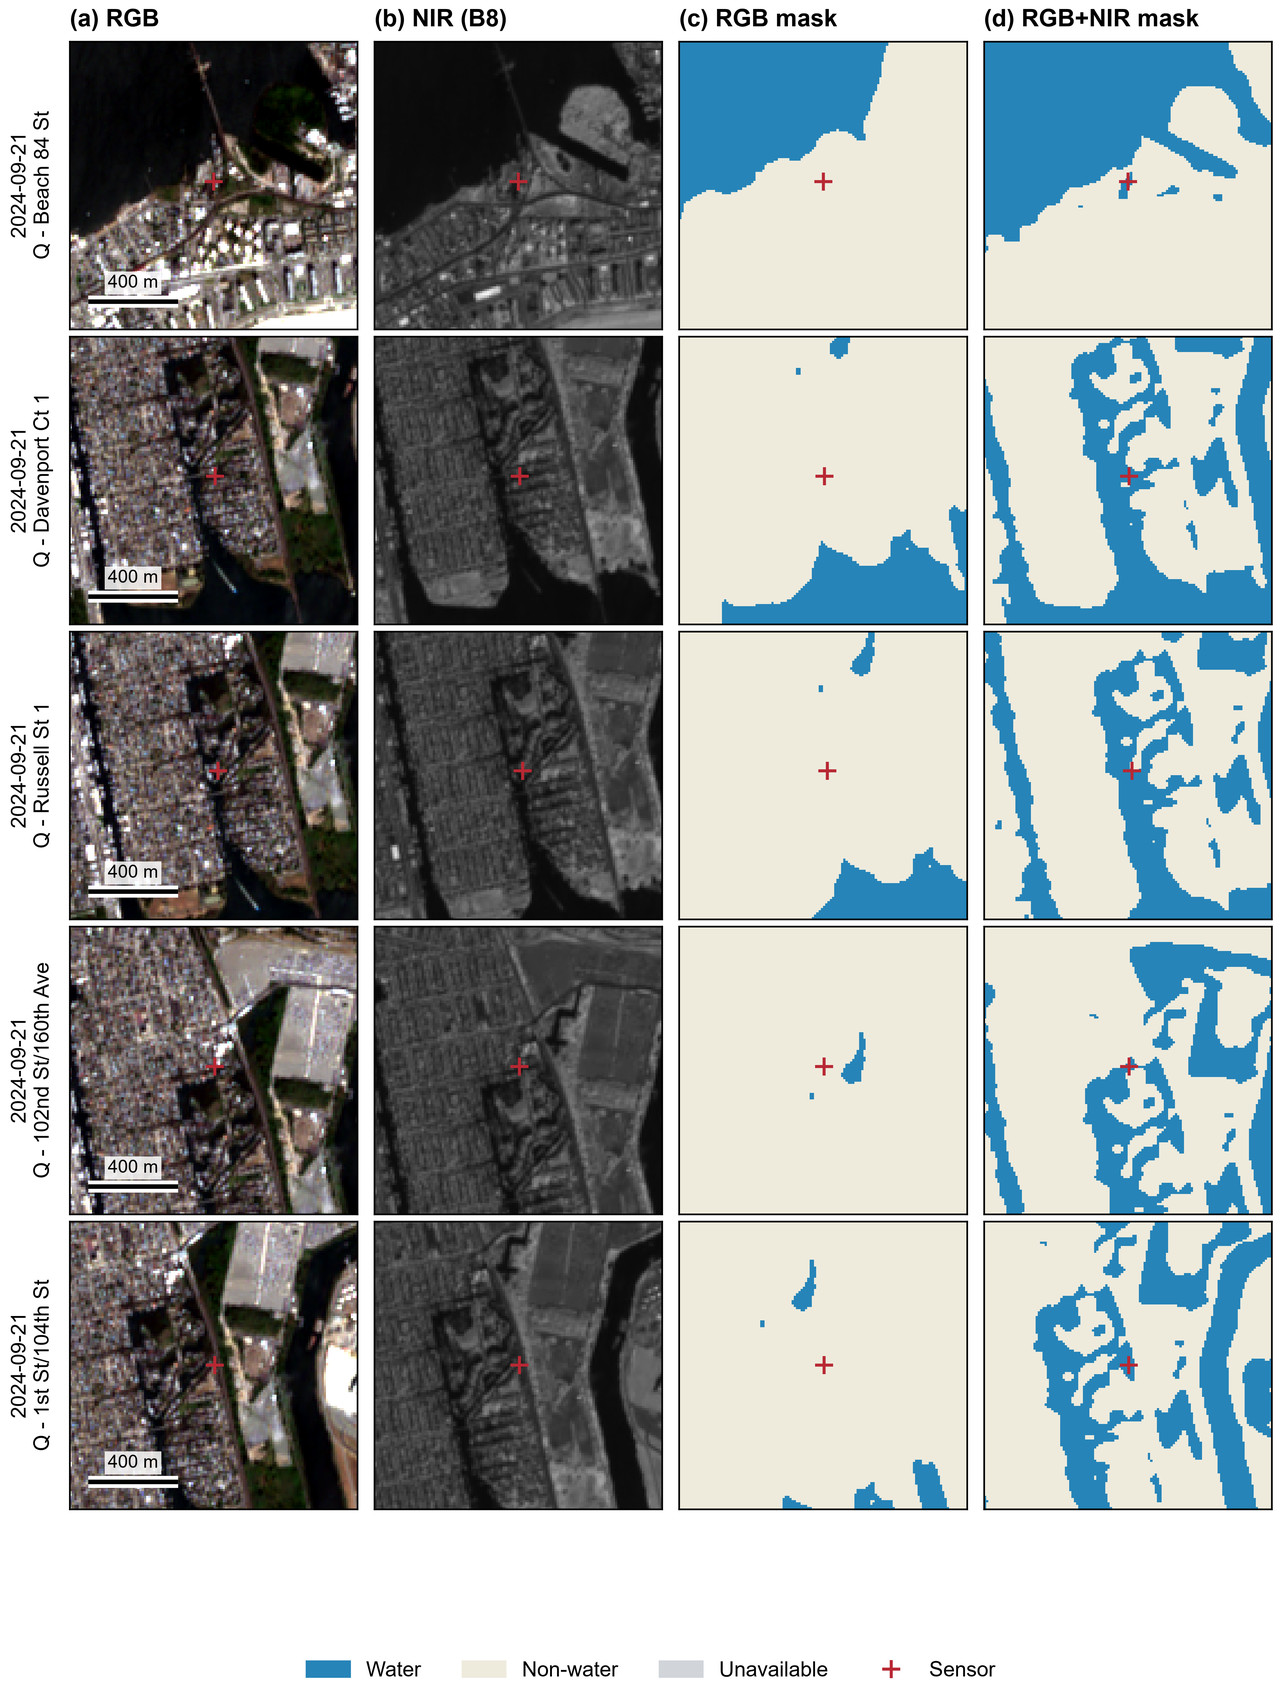

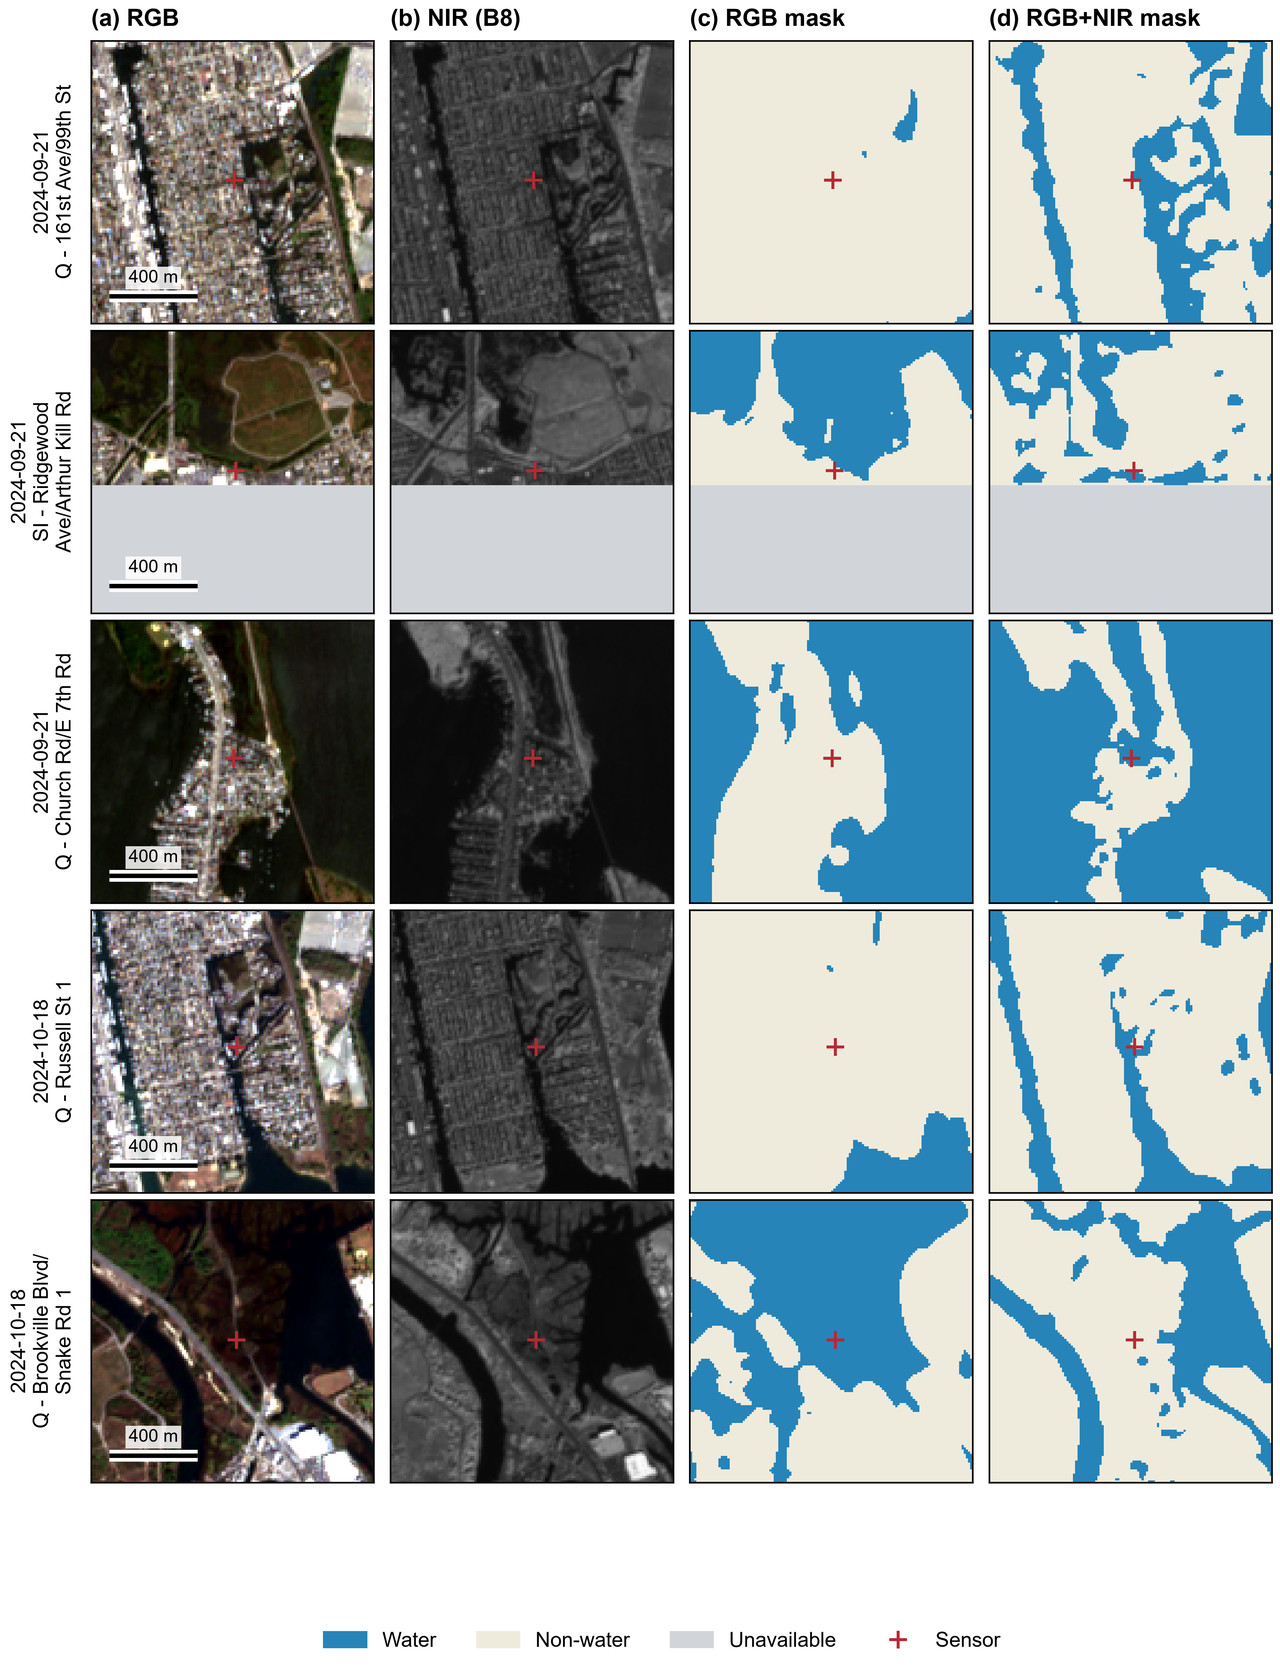

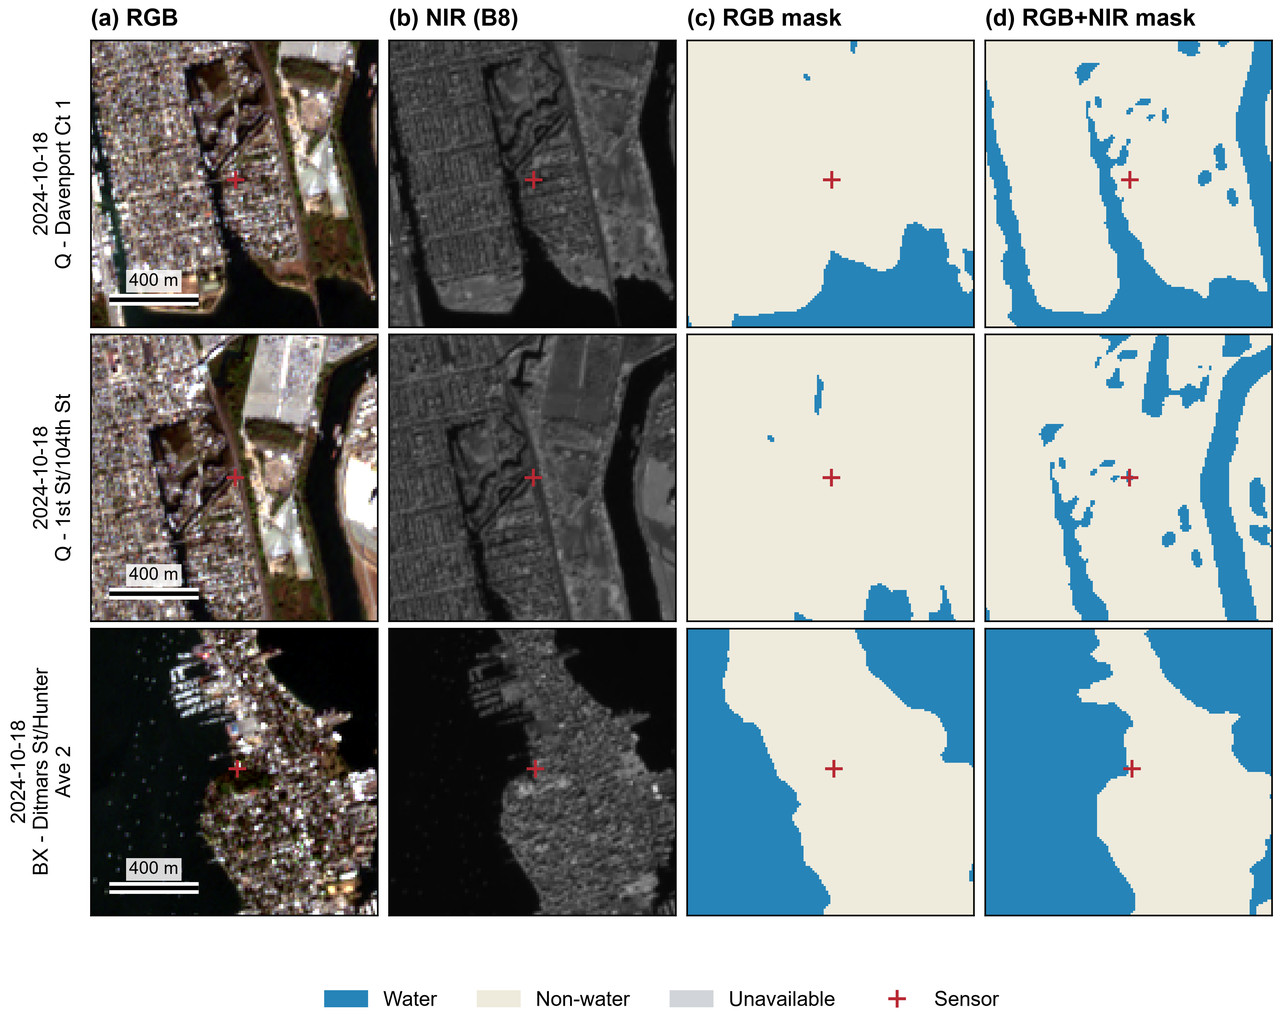

In [10]:
gallery = ''.join('<img alt="NYC site-date atlas" src="data:image/png;base64,' + base64.b64encode(PAPER[f'gallery{i}'].read_bytes()).decode() + '">' for i in range(1,4))
display(HTML('<details><summary>Supplementary atlas: all 13 NYC site–date windows</summary><p class="caption">Original record order. All 13 windows retained; each five-row page uses a common RGB display stretch, fixed NIR range and shared mask colors. Grey areas denote unavailable pixels.</p>' + gallery + '</details>'))